Complete case analysis in handling missing data is a common approach where only the cases with complete data are analyzed, and cases with any missing values are excluded from the analysis. This method is straightforward and easy to implement, but it can lead to biased results if the missing data is not completely random (MCAR).When using complete case analysis, it is important to assess the pattern of missing data and consider whether theexcluded cases differ systematically from the included cases. If the missing data is related to the outcome or othervariables, the results may not be generalizable to the entire population.


when to use cca?
it is used when only 5% of the data is missing and the missing data is completely random (MCAR). It is also used when the sample size is large enough to still have sufficient power after excluding cases with missing data. However, it is important to note that if the missing data is not MCAR, complete case analysis can lead to biased results and should be avoided.\


In [1]:
import pandas as pd 
import numpy as np

In [2]:
df=pd.read_csv('./data_science_job.csv')

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [4]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [7]:
cols=[var for var in df.columns if  df[var].isnull().mean()<0.05 and df[var].isnull().mean()>0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [8]:
len(df[cols].dropna())/len(df)

0.8968577095730244

In [10]:
new_df=df[cols].dropna()
df.shape,new_df.shape

((19158, 13), (17182, 5))

array([[<Axes: title={'center': 'city_development_index'}>,
        <Axes: title={'center': 'experience'}>],
       [<Axes: title={'center': 'training_hours'}>, <Axes: >]],
      dtype=object)

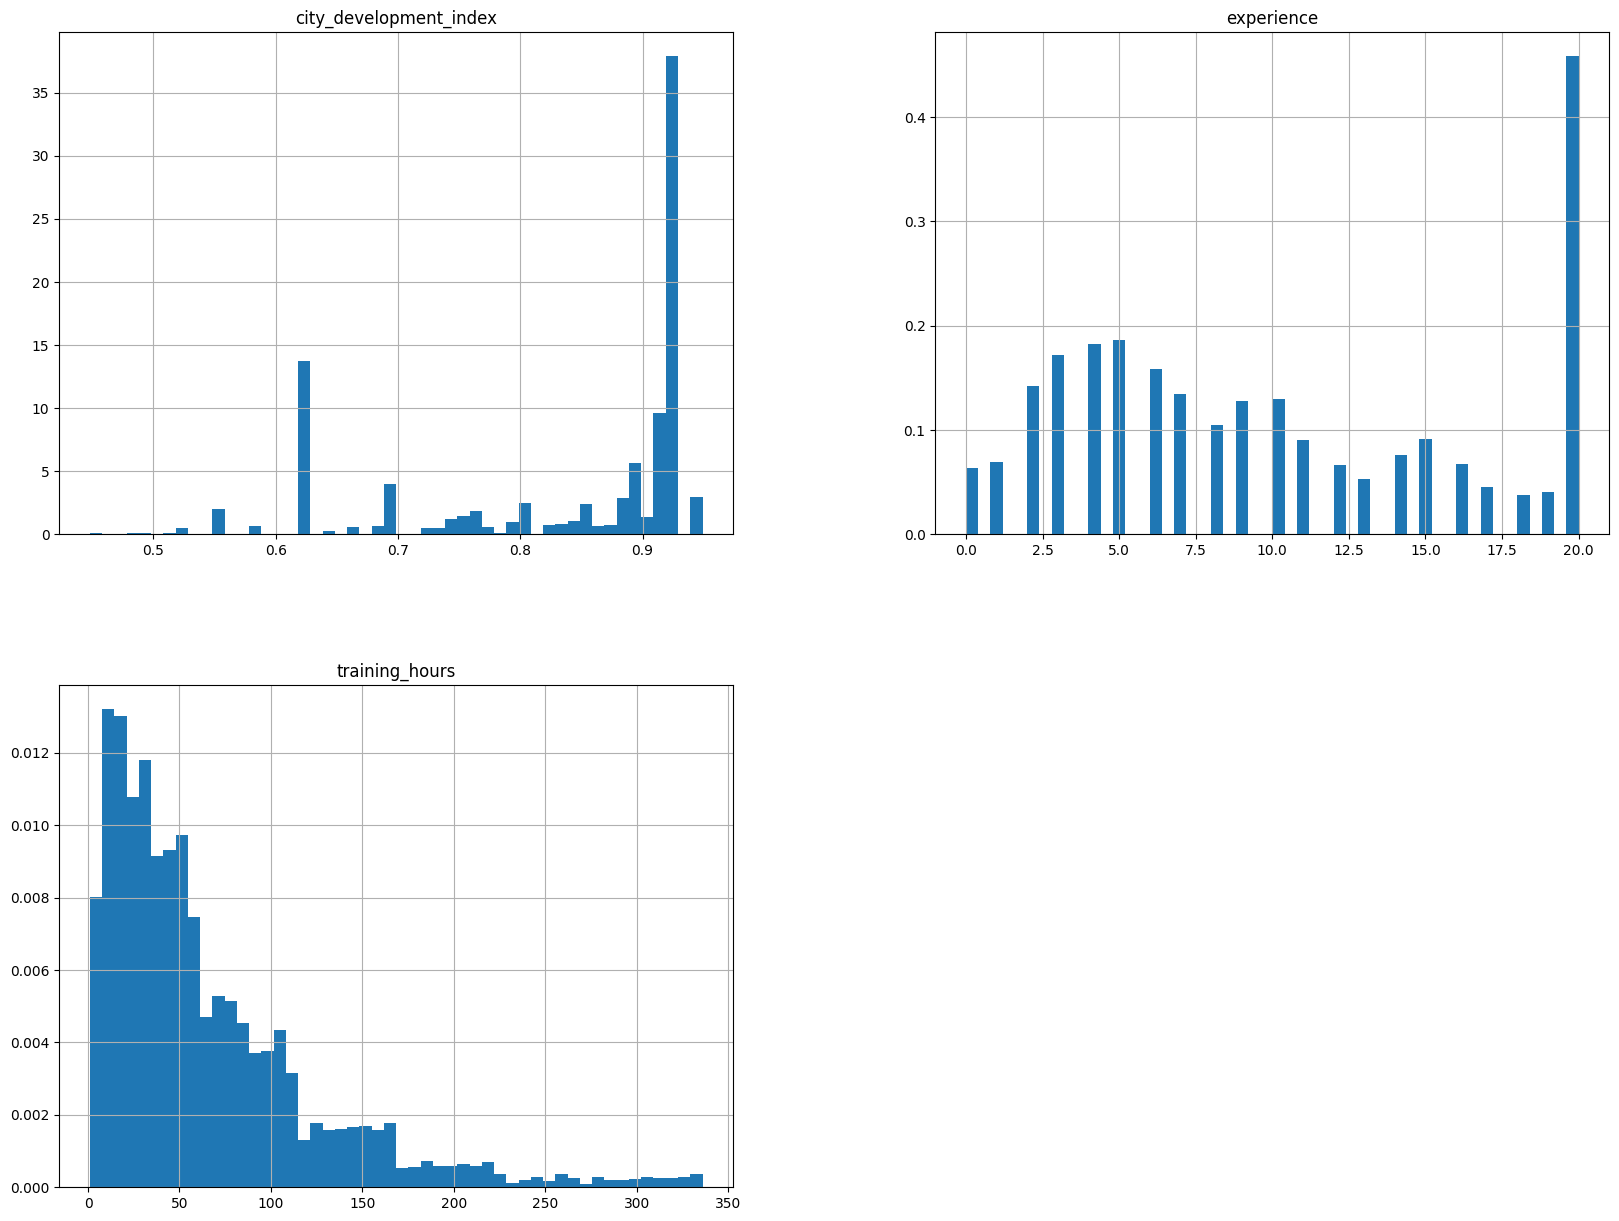

In [13]:
new_df.hist(bins=50,density=True,figsize=(20,15))

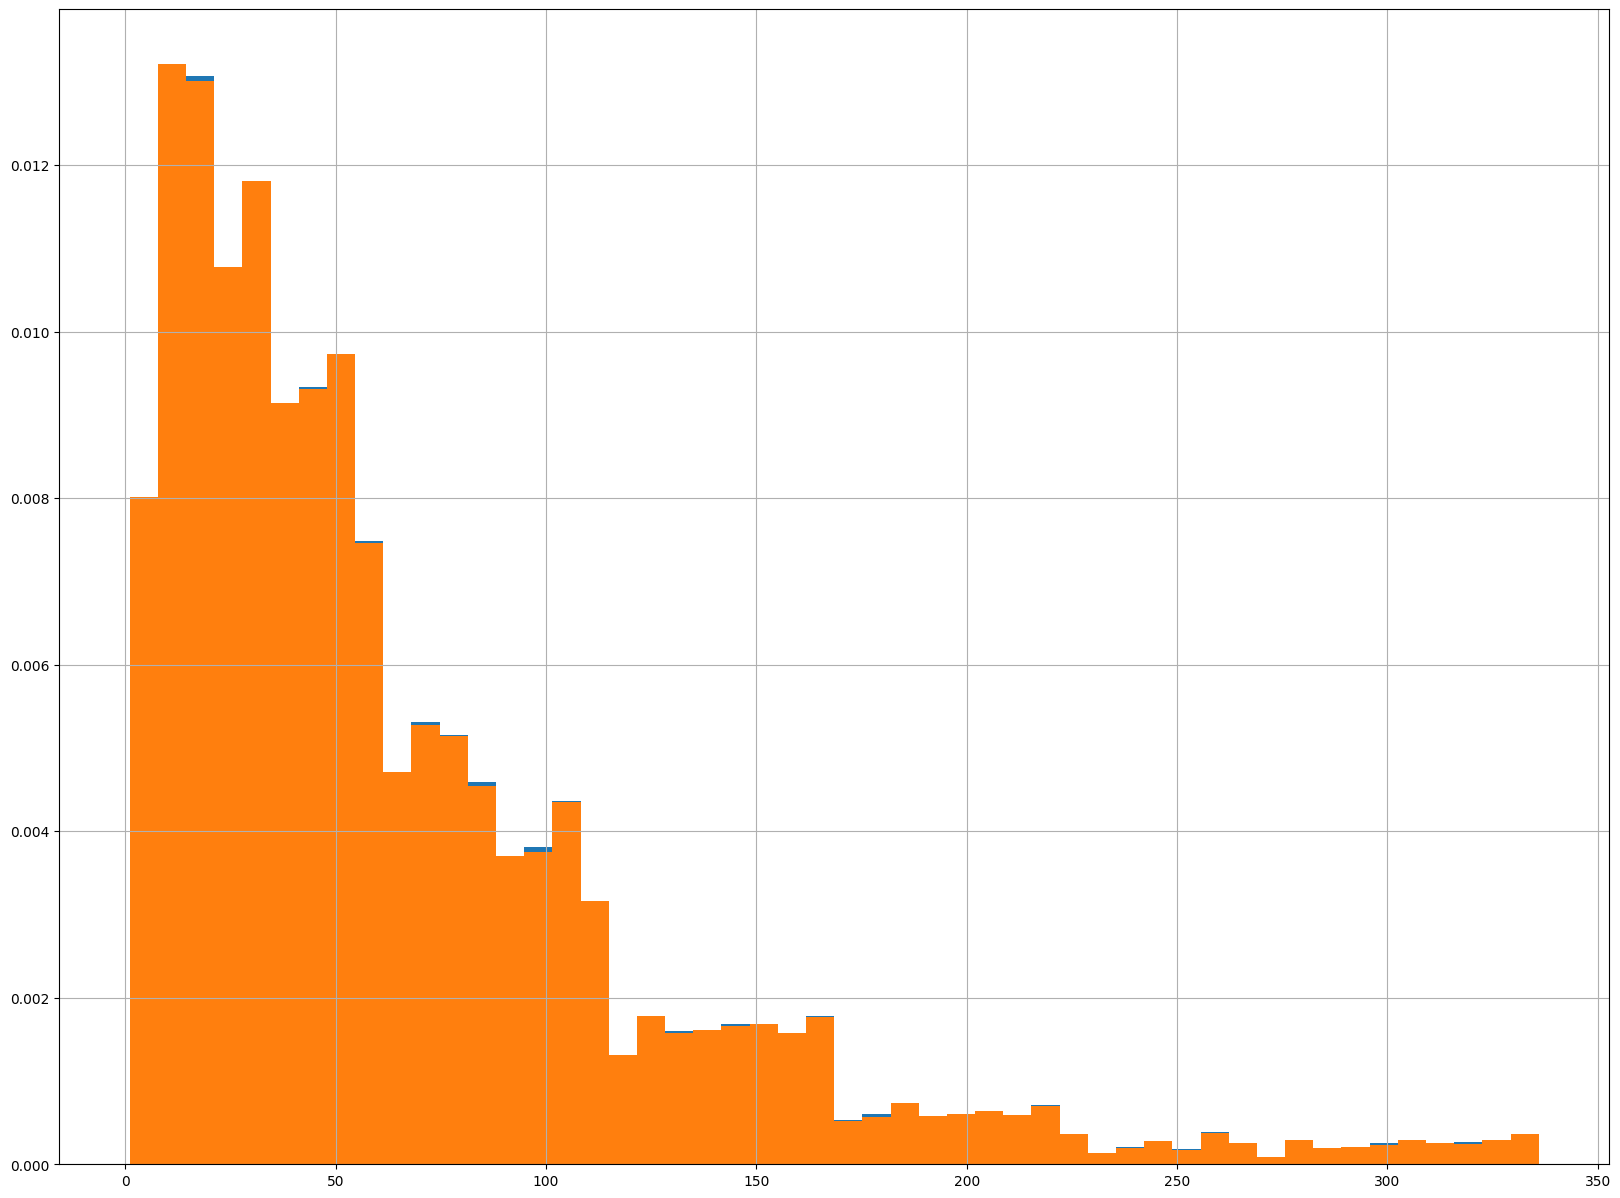

In [15]:
import matplotlib.pyplot as plt
fig=plt.figure(figsize=(20,15))
ax=fig.add_subplot(111)
df['training_hours'].hist(bins=50,density=True,ax=ax)
new_df['training_hours'].hist(bins=50,density=True,ax=ax)
plt.show()
